In [1]:
from glob import glob
import os
import pandas as pd

In [2]:
!pwd

/Users/hanif/Bootcamp/Winter_1403


In [3]:
path_list = glob("./mnist-pngs/**/*.png", recursive=True)

In [4]:
path_frame = pd.DataFrame({
    "path" : path_list
})

In [5]:
path_frame["type"] = path_frame["path"].apply(lambda x: x.split("/")[-3])
path_frame["label"] = path_frame["path"].apply(lambda x: x.split("/")[-2])

In [6]:
path_frame

,path,type,label
0,./mnist-pngs/test/9/66710.png,test,9
1,./mnist-pngs/test/9/69423.png,test,9
2,./mnist-pngs/test/9/65219.png,test,9
3,./mnist-pngs/test/9/67426.png,test,9
4,./mnist-pngs/test/9/69386.png,test,9
...,...,...,...
69995,./mnist-pngs/train/5/31651.png,train,5
69996,./mnist-pngs/train/5/437.png,train,5
69997,./mnist-pngs/train/5/33734.png,train,5
69998,./mnist-pngs/train/5/40902.png,train,5


In [7]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [8]:
img = Image.open(path_frame["path"].iloc[0])

In [9]:
img = np.array(img)

In [10]:
img.shape

(28, 28)

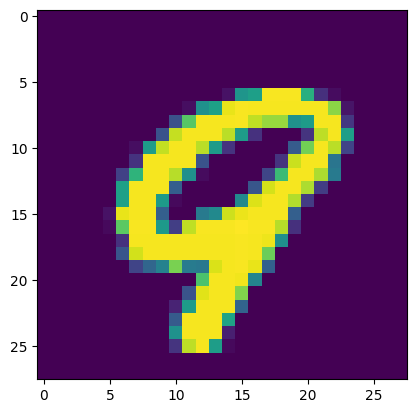

In [11]:
plt.imshow(img)

In [12]:
train_frame = path_frame[path_frame["type"]=="train"]
display(train_frame)
train_data = [np.array(Image.open(item)) for item in train_frame["path"]]

,path,type,label
10000,./mnist-pngs/train/9/36655.png,train,9
10001,./mnist-pngs/train/9/32433.png,train,9
10002,./mnist-pngs/train/9/28319.png,train,9
10003,./mnist-pngs/train/9/4968.png,train,9
10004,./mnist-pngs/train/9/23502.png,train,9
...,...,...,...
69995,./mnist-pngs/train/5/31651.png,train,5
69996,./mnist-pngs/train/5/437.png,train,5
69997,./mnist-pngs/train/5/33734.png,train,5
69998,./mnist-pngs/train/5/40902.png,train,5


In [13]:
xTrain = np.array(train_data)

In [14]:
xTrain.shape

(60000, 28, 28)

In [15]:
test_frame = path_frame[path_frame["type"]=="test"]
display(test_frame)
test_data = [np.array(Image.open(item)) for item in test_frame["path"]]
xTest = np.array(test_data)

,path,type,label
0,./mnist-pngs/test/9/66710.png,test,9
1,./mnist-pngs/test/9/69423.png,test,9
2,./mnist-pngs/test/9/65219.png,test,9
3,./mnist-pngs/test/9/67426.png,test,9
4,./mnist-pngs/test/9/69386.png,test,9
...,...,...,...
9995,./mnist-pngs/test/5/66053.png,test,5
9996,./mnist-pngs/test/5/64888.png,test,5
9997,./mnist-pngs/test/5/63117.png,test,5
9998,./mnist-pngs/test/5/67403.png,test,5


In [16]:
xTest.shape

(10000, 28, 28)

In [17]:
yTrain = train_frame["label"].values.astype(int)
yTest = test_frame["label"].values.astype(int)

In [18]:
# normalization

In [19]:
xTrain = xTrain / 255
xTest = xTest / 255

In [24]:
xTrain.shape

(60000, 28, 28)

In [30]:
xTrain = np.expand_dims(xTrain, -1)

In [32]:
xTest = np.expand_dims(xTest, -1)

In [33]:
import tensorflow as tf
from tensorflow.keras import layers

In [61]:
input_layer = tf.keras.Input(shape=(xTrain.shape[1:]))

# Feature Extractor
model = layers.Conv2D(64, kernel_size=3, activation="elu", strides=1, padding="valid")(input_layer)
model = layers.MaxPooling2D(pool_size=2)(model)
model = layers.BatchNormalization()(model)
model = layers.Dropout(0.2)(model)

model = layers.Conv2D(32, kernel_size=3, activation="elu", strides=2, padding="valid")(model)
model = layers.MaxPooling2D(pool_size=2)(model)
model = layers.Dropout(0.2)(model)

model = layers.Flatten()(model)

# fully connected network (classifier)
model = layers.Dense(16, activation="elu")(model)
model = layers.Dropout(0.2)(model)
model = layers.Dense(len(np.unique(yTrain)), activation="softmax")(model)

model = tf.keras.Model(input_layer, model)
model.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_23 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 6, 6, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,154 (94.35 KB)

 Trainable params: 24,026 (93.85 KB)

 Non-trainable params: 128 (512.00 B)

In [54]:
model.compile(optimizer="adam", loss="categorical_crossentropy")

In [55]:
model.fit(xTrain, tf.keras.utils.to_categorical(yTrain), epochs=50, batch_size=512, validation_split=0.3)

Epoch 1/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 22s 248ms/step - loss: 1.6225 - val_loss: 6.2177
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 255ms/step - loss: 0.4638 - val_loss: 7.1089
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 248ms/step - loss: 0.2782 - val_loss: 6.8861
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 248ms/step - loss: 0.2187 - val_loss: 7.2121
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 255ms/step - loss: 0.1705 - val_loss: 7.4686
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 256ms/step - loss: 0.1593 - val_loss: 7.8118
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 251ms/step - loss: 0.1433 - val_loss: 7.6043
Epoch 8/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 258ms/step - loss: 0.1304 - val_loss: 8.0065
Epoch 9/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 22s 262ms/step - loss: 0.1157 - val_loss: 7.8700
Epoch 10/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 22s 261ms/step - loss: 0.1109 - val_loss: 8.1635
Epoch 11/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 22s 262ms/step - loss: 0.1114 - val_loss: 8.1873
Epoch 12/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 21

In [56]:
y_pred = np.argmax(model.predict(xTest), 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [57]:
from sklearn.metrics import classification_report

In [58]:
print(classification_report(yTest, y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94       980
           1       0.87      1.00      0.93      1135
           2       0.00      0.00      0.00      1032
           3       0.00      0.00      0.00      1010
           4       0.96      0.99      0.98       982
           5       0.00      0.00      0.00       892
           6       0.90      0.99      0.94       958
           7       0.72      0.99      0.83      1028
           8       0.40      0.99      0.57       974
           9       0.58      0.99      0.73      1009

    accuracy                           0.70     10000
   macro avg       0.53      0.69      0.59     10000
weighted avg       0.54      0.70      0.60     10000



/Users/hanif/miniconda3/envs/mlseq/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/hanif/miniconda3/envs/mlseq/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/hanif/miniconda3/envs/mlseq/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz